In [18]:
# ====================== 1. NẠP THƯ VIỆN ======================
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import FuncFormatter
from mlxtend.frequent_patterns import apriori, association_rules

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [19]:
# ====================== 2. CÀI ĐẶT THƯ VIỆN BỔ SUNG ======================
!pip -q install mlxtend

In [20]:
# ====================== 3. LOAD DATA ======================
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/2321004016_VuNgocLinh_DoAn/data/online_retail_II.csv'
raw_dataset = pd.read_csv(DATA_PATH, encoding='latin1')



In [21]:
# ====================== 4. CÁC HÀM HỖ TRỢ ======================
def load_and_clean_data(path):
    df = pd.read_csv(path, encoding='latin1')
    df.columns = [col.strip().replace('Customer ID', 'CustomerID') for col in df.columns]
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

    df = df.dropna(subset=['Description']).copy()
    df['Description'] = df['Description'].astype(str).str.strip()
    df = df[df['Description'] != ''].copy()
    df = df[(df['Quantity'] > 0) & (df['Price'] > 0)].copy()
    df = df[~df['Invoice'].astype(str).str.startswith('C')].copy()
    df['Revenue'] = df['Quantity'] * df['Price']
    return df

def build_basket(df, country='United Kingdom', top_n_products=250):
    filtered = df[df['Country'] == country].copy()

    top_products = (
        filtered.groupby('Description')['Invoice']
        .nunique()
        .sort_values(ascending=False)
        .head(top_n_products)
        .index
    )

    filtered = filtered[filtered['Description'].isin(top_products)].copy()
    basket = (
        filtered.groupby(['Invoice', 'Description'])['Quantity']
        .sum()
        .unstack(fill_value=0)
    )
    basket = basket.applymap(lambda x: 1 if x > 0 else 0)
    return filtered, basket

def format_itemset(itemset):
    return ', '.join(sorted(list(itemset)))

def linear_forecast(series, steps=3):
    y = series.to_numpy(dtype=float)
    x = np.arange(len(y), dtype=float)
    slope, intercept = np.polyfit(x, y, deg=1)
    future_x = np.arange(len(y), len(y) + steps, dtype=float)
    preds = np.maximum(intercept + slope * future_x, 0.0)
    return preds, float(slope)

def classify_trend(slope):
    if slope > 0:
        return 'Tăng'
    if slope < 0:
        return 'Giảm'
    return 'Ổn định'

In [22]:
print('=== KÍCH THƯỚC DỮ LIỆU GỐC ===')
print(f'Số dòng: {raw_dataset.shape[0]:,} | Số cột: {raw_dataset.shape[1]}')
display(raw_dataset.head())

=== KÍCH THƯỚC DỮ LIỆU GỐC ===
Số dòng: 1,067,371 | Số cột: 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.9500,"13,085.0000",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,"13,085.0000",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,"13,085.0000",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.1000,"13,085.0000",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.2500,"13,085.0000",United Kingdom


In [23]:
# ====================== 5. KHÁM PHÁ DỮ LIỆU (EDA) ======================
print('=== THÔNG TIN TỔNG QUAN ===')
print(raw_dataset.info())

print('\n=== GIÁ TRỊ THIẾU ===')
display(raw_dataset.isnull().sum().sort_values(ascending=False).to_frame('Missing'))

print('\n=== THỐNG KÊ NHANH ===')
print('Số invoice hủy:', raw_dataset['Invoice'].astype(str).str.startswith('C').sum())
print('Số dòng Quantity <= 0:', (raw_dataset['Quantity'] <= 0).sum())
print('Số dòng Price <= 0:', (raw_dataset['Price'] <= 0).sum())
print('Số quốc gia:', raw_dataset['Country'].nunique())

=== THÔNG TIN TỔNG QUAN ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None

=== GIÁ TRỊ THIẾU ===


,Missing
Customer ID,243007
Description,4382
StockCode,0
Invoice,0
Quantity,0
InvoiceDate,0
Price,0
Country,0



=== THỐNG KÊ NHANH ===
Số invoice hủy: 19494
Số dòng Quantity <= 0: 22950
Số dòng Price <= 0: 6207
Số quốc gia: 43


In [24]:
# ====================== 6. TIỀN XỬ LÝ DỮ LIỆU ======================
dataset = load_and_clean_data(DATA_PATH)

print('=== DỮ LIỆU SAU KHI LÀM SẠCH ===')
print(f'Số dòng còn lại: {len(dataset):,}')
print(f"Số invoice còn lại: {dataset['Invoice'].nunique():,}")
print(f"Số sản phẩm còn lại: {dataset['Description'].nunique():,}")
display(dataset.head())

=== DỮ LIỆU SAU KHI LÀM SẠCH ===
Số dòng còn lại: 1,041,670
Số invoice còn lại: 40,077
Số sản phẩm còn lại: 5,357


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.9500,"13,085.0000",United Kingdom,83.4000
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,"13,085.0000",United Kingdom,81.0000
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,"13,085.0000",United Kingdom,81.0000
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.1000,"13,085.0000",United Kingdom,100.8000
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.2500,"13,085.0000",United Kingdom,30.0000


/tmp/ipykernel_12362/3709522283.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_top.values, y=country_top.index, palette='crest', ax=axes[0])
/tmp/ipykernel_12362/3709522283.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_top.values, y=product_top.index, palette='magma', ax=axes[1])


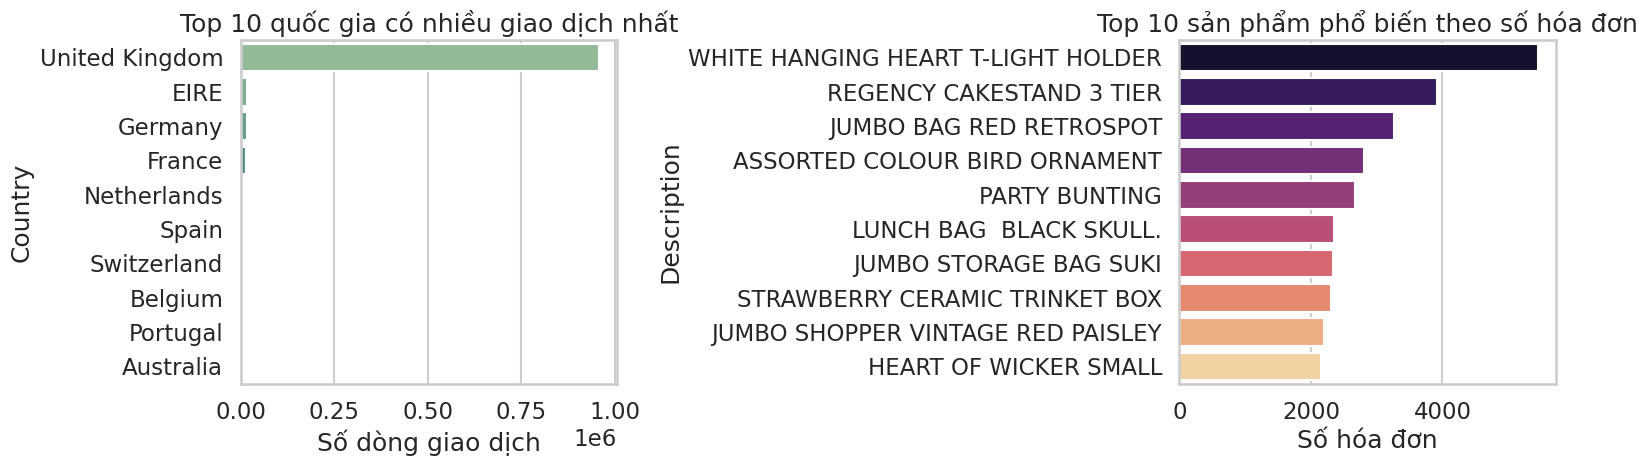

In [25]:
# Trực quan hóa ban đầu
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

country_top = dataset['Country'].value_counts().head(10)
sns.barplot(x=country_top.values, y=country_top.index, palette='crest', ax=axes[0])
axes[0].set_title('Top 10 quốc gia có nhiều giao dịch nhất')
axes[0].set_xlabel('Số dòng giao dịch')

product_top = (
    dataset.groupby('Description')['Invoice']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)
sns.barplot(x=product_top.values, y=product_top.index, palette='magma', ax=axes[1])
axes[1].set_title('Top 10 sản phẩm phổ biến theo số hóa đơn')
axes[1].set_xlabel('Số hóa đơn')

plt.tight_layout()
plt.show()

In [26]:
# ====================== 7. TẠO GIỎ HÀNG (BASKET) ======================
ANALYSIS_COUNTRY = 'United Kingdom'
TOP_N_PRODUCTS = 100

basket_source, basket = build_basket(dataset, country=ANALYSIS_COUNTRY, top_n_products=TOP_N_PRODUCTS)

print('=== BASKET DATA ===')
print(f'Quốc gia phân tích: {ANALYSIS_COUNTRY}')
print(f'Số invoice dùng cho basket: {basket.shape[0]:,}')
print(f'Số sản phẩm trong basket: {basket.shape[1]:,}')
display(basket.head())

/tmp/ipykernel_12362/3057886060.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)


=== BASKET DATA ===
Quốc gia phân tích: United Kingdom
Số invoice dùng cho basket: 27,982
Số sản phẩm trong basket: 100


Description,6 RIBBONS RUSTIC CHARM,60 TEATIME FAIRY CAKE CASES,72 SWEETHEART FAIRY CAKE CASES,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,ANTIQUE SILVER TEA GLASS ETCHED,ASSORTED COLOUR BIRD ORNAMENT,BAKING SET 9 PIECE RETROSPOT,BATHROOM METAL SIGN,BOX OF 24 COCKTAIL PARASOLS,CHARLOTTE BAG SUKI DESIGN,CHILLI LIGHTS,CHOCOLATE HOT WATER BOTTLE,CLOTHES PEGS RETROSPOT PACK 24,COLOUR GLASS T-LIGHT HOLDER HANGING,COOK WITH WINE METAL SIGN,CREAM HEART CARD HOLDER,DOLLY GIRL LUNCH BOX,DOTCOM POSTAGE,FELTCRAFT 6 FLOWER FRIENDS,FELTCRAFT BUTTERFLY HEARTS,GIN + TONIC DIET METAL SIGN,GREEN REGENCY TEACUP AND SAUCER,HAND OVER THE CHOCOLATE SIGN,HAND WARMER OWL DESIGN,HAND WARMER SCOTTY DOG DESIGN,HANGING HEART JAR T-LIGHT HOLDER,HANGING HEART ZINC T-LIGHT HOLDER,HEART OF WICKER LARGE,HEART OF WICKER SMALL,HOME BUILDING BLOCK WORD,HOT BATHS METAL SIGN,HOT WATER BOTTLE TEA AND SYMPATHY,JUMBO BAG BAROQUE BLACK WHITE,JUMBO BAG OWLS,JUMBO BAG PINK POLKADOT,JUMBO BAG PINK VINTAGE PAISLEY,JUMBO BAG RED RETROSPOT,JUMBO BAG SPACEBOY DESIGN,JUMBO BAG STRAWBERRY,JUMBO BAG WOODLAND ANIMALS,JUMBO SHOPPER VINTAGE RED PAISLEY,JUMBO STORAGE BAG SKULLS,JUMBO STORAGE BAG SUKI,LADIES & GENTLEMEN METAL SIGN,LOVE BUILDING BLOCK WORD,LOVEBIRD HANGING DECORATION WHITE,LUNCH BAG BLACK SKULL.,LUNCH BAG CARS BLUE,LUNCH BAG PINK POLKADOT,LUNCH BAG RED RETROSPOT,LUNCH BAG RED SPOTTY,LUNCH BAG SPACEBOY DESIGN,LUNCH BAG SUKI DESIGN,LUNCH BAG WOODLAND,NATURAL SLATE HEART CHALKBOARD,NO SINGING METAL SIGN,PACK OF 60 DINOSAUR CAKE CASES,PACK OF 60 PINK PAISLEY CAKE CASES,PACK OF 72 RETRO SPOT CAKE CASES,PACK OF 72 RETROSPOT CAKE CASES,PACK OF 72 SKULL CAKE CASES,PAPER CHAIN KIT 50'S CHRISTMAS,PAPER CHAIN KIT VINTAGE CHRISTMAS,PARTY BUNTING,PINK BLUE FELT CRAFT TRINKET BOX,PINK CREAM FELT CRAFT TRINKET BOX,PLEASE ONE PERSON METAL SIGN,POTTERING IN THE SHED METAL SIGN,RECIPE BOX PANTRY YELLOW DESIGN,RECYCLING BAG RETROSPOT,RED HANGING HEART T-LIGHT HOLDER,RED RETROSPOT CHARLOTTE BAG,RED TOADSTOOL LED NIGHT LIGHT,RED WOOLLY HOTTIE WHITE HEART.,REGENCY CAKESTAND 3 TIER,RETROSPOT TEA SET CERAMIC 11 PC,REX CASH+CARRY JUMBO SHOPPER,ROSES REGENCY TEACUP AND SAUCER,SCOTTIE DOG HOT WATER BOTTLE,SET OF 3 CAKE TINS PANTRY DESIGN,SET OF 3 HEART COOKIE CUTTERS,SET/5 RED RETROSPOT LID GLASS BOWLS,SINGLE HEART ZINC T-LIGHT HOLDER,SMALL POPCORN HOLDER,SPACEBOY LUNCH BOX,STRAWBERRY CERAMIC TRINKET BOX,STRAWBERRY CHARLOTTE BAG,SWEETHEART CERAMIC TRINKET BOX,VICTORIAN GLASS HANGING T-LIGHT,VINTAGE HEADS AND TAILS CARD GAME,VINTAGE SNAP CARDS,VINTAGE UNION JACK BUNTING,WHITE HANGING HEART T-LIGHT HOLDER,WOOD 2 DRAWER CABINET WHITE FINISH,WOOD BLACK BOARD ANT WHITE FINISH,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,WOODLAND CHARLOTTE BAG,ZINC METAL HEART DECORATION
Invoice,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
489434,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
489436,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
489437,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
489441,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
489442,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0


## 9. Áp Dụng Apriori Algorithm


In [27]:
# ====================== 8. HUẤN LUYỆN MÔ HÌNH APRIORI ======================
MIN_SUPPORT = 0.02
MIN_CONFIDENCE = 0.35
MIN_LIFT = 1.2

frequent_itemsets = apriori(basket, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets['itemset_len'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets['itemsets_text'] = frequent_itemsets['itemsets'].apply(format_itemset)

rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=MIN_CONFIDENCE)
rules = rules[rules['lift'] >= MIN_LIFT].copy()
rules['antecedents_text'] = rules['antecedents'].apply(format_itemset)
rules['consequents_text'] = rules['consequents'].apply(format_itemset)
rules = rules.sort_values(['lift', 'confidence', 'support'], ascending=False)

print('=== KẾT QUẢ APRIORI ===')
print(f'Số tập phổ biến tìm được: {len(frequent_itemsets):,}')
print(f'Số luật kết hợp tìm được: {len(rules):,}')

=== KẾT QUẢ APRIORI ===
Số tập phổ biến tìm được: 187
Số luật kết hợp tìm được: 102


In [28]:
# ====================== 9. ĐÁNH GIÁ KẾT QUẢ ======================
display(
    frequent_itemsets[['support', 'itemset_len', 'itemsets_text']]
    .sort_values(['itemset_len', 'support'], ascending=[True, False])
    .head(20)
)

display(
    rules[['antecedents_text', 'consequents_text', 'support', 'confidence', 'lift']]
    .head(20)
)

,support,itemset_len,itemsets_text
93,0.1877,1,WHITE HANGING HEART T-LIGHT HOLDER
75,0.1229,1,REGENCY CAKESTAND 3 TIER
37,0.1089,1,JUMBO BAG RED RETROSPOT
6,0.0946,1,ASSORTED COLOUR BIRD ORNAMENT
64,0.0906,1,PARTY BUNTING
47,0.0805,1,LUNCH BAG BLACK SKULL.
43,0.0796,1,JUMBO STORAGE BAG SUKI
86,0.0768,1,STRAWBERRY CERAMIC TRINKET BOX
41,0.0753,1,JUMBO SHOPPER VINTAGE RED PAISLEY
29,0.0750,1,HEART OF WICKER SMALL


,antecedents_text,consequents_text,support,confidence,lift
26,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.0334,0.7589,16.7347
27,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.0334,0.7368,16.7347
21,SPACEBOY LUNCH BOX,DOLLY GIRL LUNCH BOX,0.0231,0.6150,15.8175
22,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,0.0231,0.5947,15.8175
6,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,0.0265,0.6483,14.9060
7,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.0265,0.6089,14.9060
28,HAND WARMER SCOTTY DOG DESIGN,HAND WARMER OWL DESIGN,0.0229,0.6068,14.5623
29,HAND WARMER OWL DESIGN,HAND WARMER SCOTTY DOG DESIGN,0.0229,0.5506,14.5623
88,PINK BLUE FELT CRAFT TRINKET BOX,PINK CREAM FELT CRAFT TRINKET BOX,0.0223,0.5755,11.9731
87,PINK CREAM FELT CRAFT TRINKET BOX,PINK BLUE FELT CRAFT TRINKET BOX,0.0223,0.4647,11.9731


/tmp/ipykernel_12362/2376522325.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_single_items, x='support', y='item', palette='viridis')


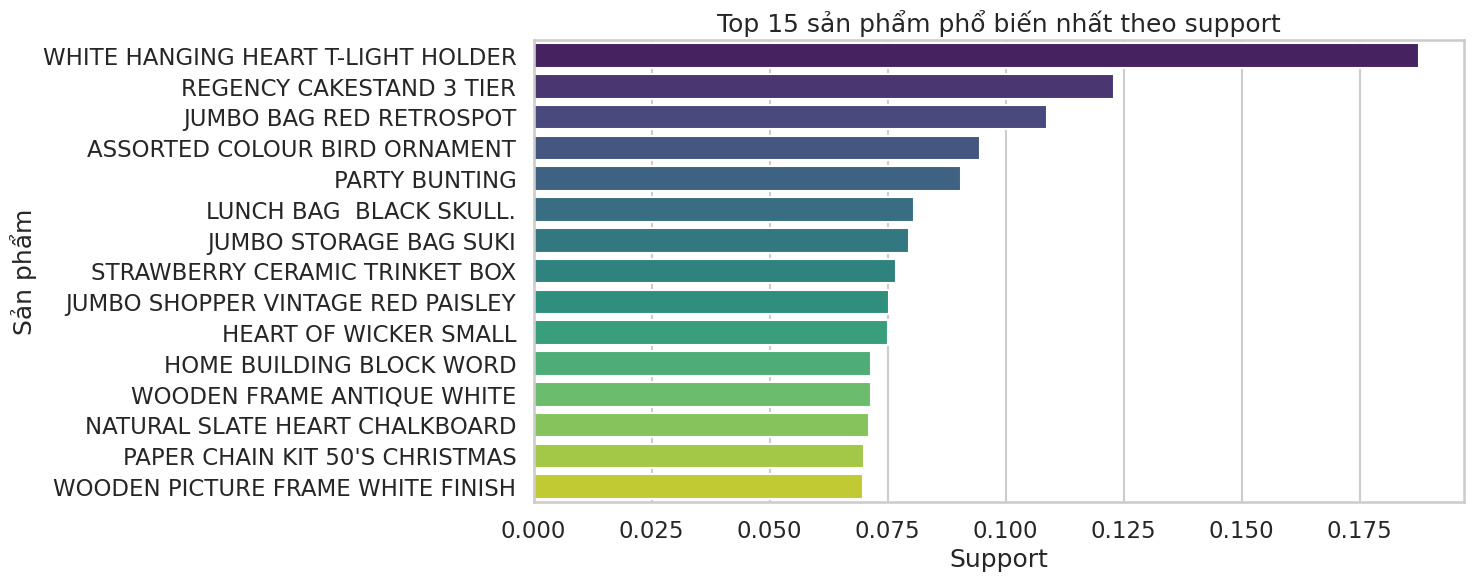

In [29]:
# ====================== 10. TRỰC QUAN HÓA KẾT QUẢ ======================
top_single_items = frequent_itemsets[frequent_itemsets['itemset_len'] == 1].copy()
top_single_items['item'] = top_single_items['itemsets'].apply(lambda x: list(x)[0])
top_single_items = top_single_items.sort_values('support', ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_single_items, x='support', y='item', palette='viridis')
plt.title('Top 15 sản phẩm phổ biến nhất theo support')
plt.xlabel('Support')
plt.ylabel('Sản phẩm')
plt.show()

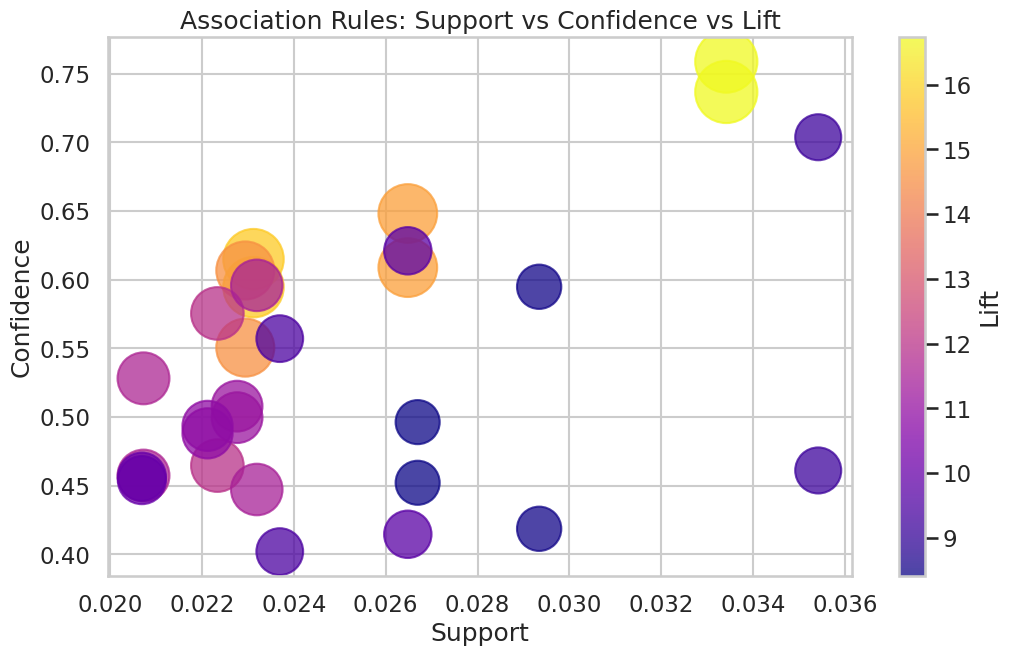

In [30]:
# Bubble chart cho association rules
top_rules_plot = rules.head(30).copy()

plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    top_rules_plot['support'],
    top_rules_plot['confidence'],
    s=top_rules_plot['lift'] * 120,
    c=top_rules_plot['lift'],
    cmap='plasma',
    alpha=0.75,
)
plt.colorbar(scatter, label='Lift')
plt.title('Association Rules: Support vs Confidence vs Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.show()

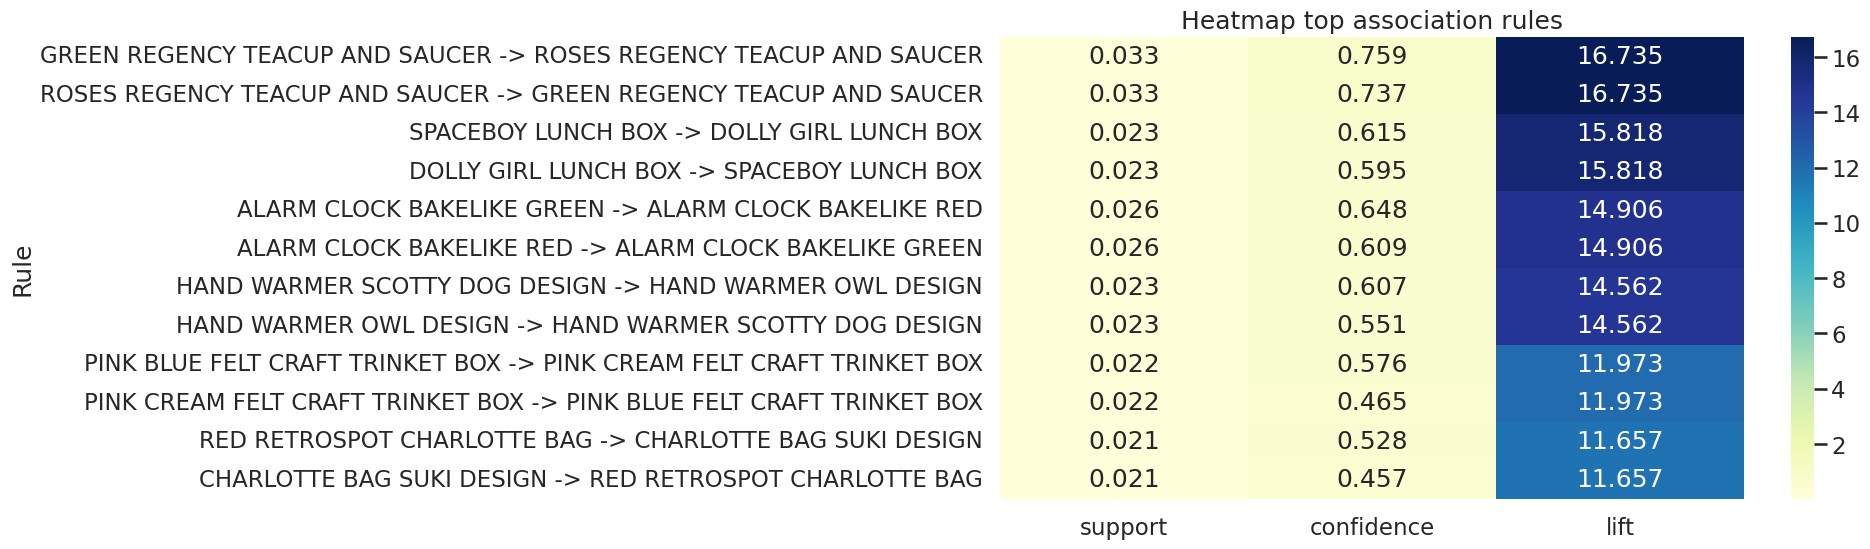

In [31]:
# Heatmap top luật kết hợp
heatmap_rules = rules.head(12).copy()
heatmap_rules['Rule'] = heatmap_rules['antecedents_text'] + ' -> ' + heatmap_rules['consequents_text']
heatmap_view = heatmap_rules.set_index('Rule')[['support', 'confidence', 'lift']]

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_view, annot=True, fmt='.3f', cmap='YlGnBu')
plt.title('Heatmap top association rules')
plt.show()

## 12. Phần Giả Định/Mô Phỏng Gợi Ý Sản Phẩm

In [32]:
# ====================== 11. GỢI Ý SẢN PHẨM THEO LUẬT KẾT HỢP ======================
seed_product = top_single_items.iloc[0]['item']
recommendations = rules[rules['antecedents'].apply(lambda x: seed_product in x)].copy()
recommendations = recommendations[['antecedents_text', 'consequents_text', 'support', 'confidence', 'lift']].head(10)

print(f'Sản phẩm giả định khách hàng đã mua: {seed_product}')
display(recommendations)

Sản phẩm giả định khách hàng đã mua: WHITE HANGING HEART T-LIGHT HOLDER


,antecedents_text,consequents_text,support,confidence,lift


In [33]:
# ====================== 12. XU HƯỚNG TIÊU DÙNG THEO THỜI GIAN ======================
monthly_trend = (
    dataset.assign(MonthStart=dataset['InvoiceDate'].dt.to_period('M').dt.to_timestamp())
    .groupby('MonthStart')
    .agg(
        Revenue=('Revenue', 'sum'),
        Orders=('Invoice', 'nunique'),
        Quantity=('Quantity', 'sum'),
    )
    .reset_index()
)

last_timestamp = dataset['InvoiceDate'].max()
if last_timestamp.day < last_timestamp.days_in_month:
    monthly_trend = monthly_trend[monthly_trend['MonthStart'] < last_timestamp.to_period('M').to_timestamp()].copy()

monthly_trend['MonthLabel'] = monthly_trend['MonthStart'].dt.strftime('%Y-%m')

forecast_df = pd.DataFrame({
    'MonthStart': pd.date_range(monthly_trend['MonthStart'].max() + pd.offsets.MonthBegin(1), periods=3, freq='MS')
})
forecast_df['MonthLabel'] = forecast_df['MonthStart'].dt.strftime('%Y-%m')

trend_slopes = {}
for metric in ['Revenue', 'Orders', 'Quantity']:
    preds, slope = linear_forecast(monthly_trend[metric], steps=3)
    forecast_df[metric] = preds
    trend_slopes[metric] = slope

display(monthly_trend[['MonthLabel', 'Revenue', 'Orders', 'Quantity']].tail(12))
display(forecast_df[['MonthLabel', 'Revenue', 'Orders', 'Quantity']])

for metric, slope in trend_slopes.items():
    print(f'{metric}: {classify_trend(slope)} ({slope:,.2f}/tháng)')

,MonthLabel,Revenue,Orders,Quantity
12,2010-12,"1,262,598.7900",1559,540198
13,2011-01,"691,364.5600",1086,387785
14,2011-02,"523,631.8900",1100,283555
15,2011-03,"717,639.3600",1454,377526
16,2011-04,"537,808.6210",1246,308815
17,2011-05,"770,536.0200",1681,395738
18,2011-06,"761,739.9000",1533,389213
19,2011-07,"719,221.1910",1475,401759
20,2011-08,"759,138.3800",1361,421770
21,2011-09,"1,058,590.1720",1837,570820


,MonthLabel,Revenue,Orders,Quantity
0,2011-12,"1,022,205.0415","1,860.9022","523,049.8442"
1,2012-01,"1,036,202.1652","1,878.9143","527,873.6451"
2,2012-02,"1,050,199.2889","1,896.9265","532,697.4459"


Revenue: Tăng (13,997.12/tháng)
Orders: Tăng (18.01/tháng)
Quantity: Tăng (4,823.80/tháng)


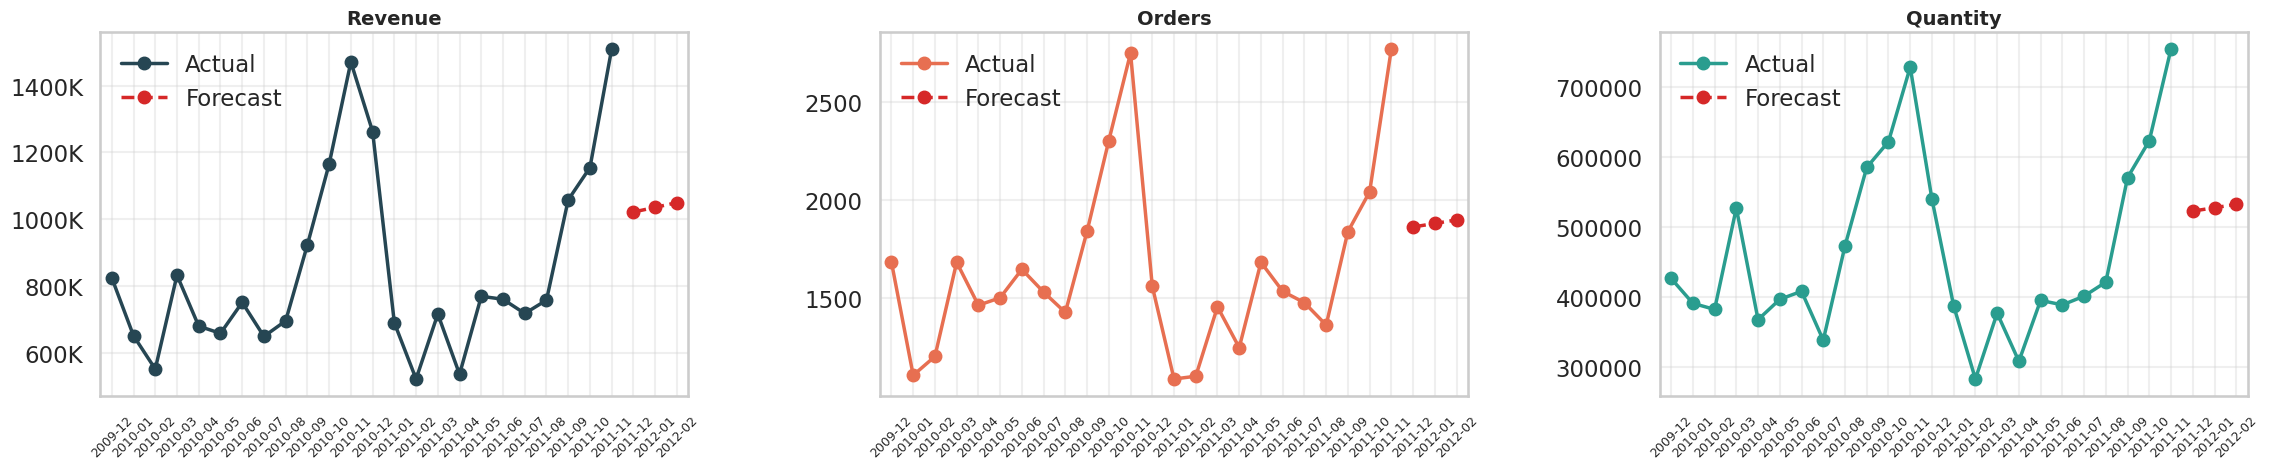

In [34]:
# Trực quan hóa xu hướng tiêu dùng
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

metrics = ['Revenue', 'Orders', 'Quantity']
colors = ['#264653', '#E76F51', '#2A9D8F']

for ax, metric, color in zip(axes, metrics, colors):

    # Actual
    ax.plot(
        monthly_trend['MonthLabel'],
        monthly_trend[metric],
        marker='o',
        linewidth=2.5,
        color=color,
        label='Actual'
    )

    # Forecast
    ax.plot(
        forecast_df['MonthLabel'],
        forecast_df[metric],
        marker='o',
        linestyle='--',
        linewidth=2.5,
        color='#D62828',
        label='Forecast'
    )
    # Title
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.margins(x=0.02)
    # Grid nhẹ
    ax.grid(alpha=0.3)
    # Legend gọn
    ax.legend(frameon=False)
# Format tiền
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:.0f}K'))

plt.tight_layout(pad=3.0)